<a href="https://colab.research.google.com/github/kixcz/ml-projects-compilation/blob/main/KNN_Visual_Learning_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors (KNN): Visual Learning Notebook

**Objectives:** (1) see how KNN classifies an unseen point, (2) visualize Euclidean distance and nearest neighbors, (3) compare decision boundaries across K, (4) measure classification performance, (5) see why scaling matters, and (6) demonstrate KNN regression.

Run cells from top to bottom (`Runtime → Run all`). No data uploads or additional packages required. All data are synthetic and not real student records.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

SEED = 42
COLORS = ["#2563eb", "#f97316"]
CMAP = ListedColormap(COLORS)
plt.rcParams.update({"figure.figsize": (8, 5.5), "axes.grid": True, "grid.alpha": 0.18, "font.size": 11})
print("Libraries imported. Random seed:", SEED)

Libraries imported. Random seed: 42


## 1. Generate a two-feature dummy dataset
Imagine two measurements of a student: **practice hours per week** and **practice quiz score**. The two labels are just hypothetical groups (**Group A**, **Group B**). KNN will infer the label of a new student by looking at nearby points. We deliberately create two partly overlapping clusters for illustration.

In [2]:
X_raw, y = make_blobs(n_samples=140, centers=[(3.0, 38.0), (7.1, 76.0)], cluster_std=[1.65, 1.9], random_state=SEED)
# Both displayed axes have understandable units; training uses standardized features later.
df = pd.DataFrame({"Practice hours": X_raw[:, 0], "Quiz score": X_raw[:, 1], "Group": np.where(y == 0, "Group A", "Group B")})
display(df.head(10))
print("Class counts:\n", df["Group"].value_counts().to_string())

,Practice hours,Quiz score,Group
0,4.836523,77.247452,Group B
1,7.210597,73.828356,Group B
2,3.968314,41.614252,Group A
3,7.999151,75.861625,Group B
4,8.078567,76.976193,Group B
5,5.409923,74.449960,Group B
6,-0.165973,37.956252,Group A
7,6.251622,77.627158,Group B
8,5.235134,76.877997,Group B
9,4.885658,39.240690,Group A


Class counts:
 Group
Group B    70
Group A    70


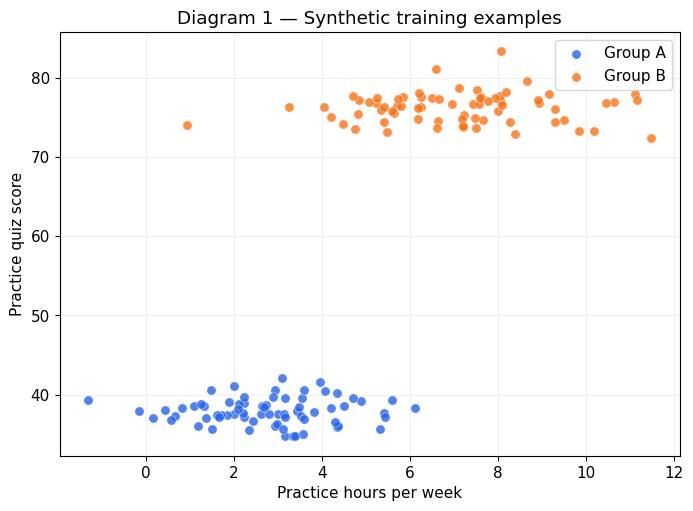

In [3]:
fig, ax = plt.subplots()
for label, c in [(0, COLORS[0]), (1, COLORS[1])]:
    pts = X_raw[y == label]
    ax.scatter(pts[:, 0], pts[:, 1], s=45, color=c, alpha=0.8, label=f"Group {chr(65+label)}", edgecolor="white", linewidth=0.4)
ax.set(xlabel="Practice hours per week", ylabel="Practice quiz score", title="Diagram 1 — Synthetic training examples")
ax.legend()
plt.show()

## 2. How KNN works: find the closest K points
We split the data **before** fitting the scaler to prevent data leakage. The classifier uses standardized inputs because quiz scores and practice hours use different numeric scales.

The highlighted new point comes from the held-out test set; it is not included in the training examples. **K = 5** means KNN inspects the five nearest training observations.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.25, stratify=y, random_state=SEED)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
new_raw = X_test[0]
new_scaled = X_test_scaled[0]
K = 5
neighbors = NearestNeighbors(n_neighbors=K).fit(X_train_scaled)
distances, indices = neighbors.kneighbors([new_scaled])
neighbor_labels = y_train[indices[0]]
predicted_group = np.bincount(neighbor_labels, minlength=2).argmax()
neighbor_table = pd.DataFrame({"Rank": np.arange(1,K+1), "Training index": indices[0], "Scaled Euclidean distance": distances[0].round(3), "Group": [f"Group {chr(65+v)}" for v in neighbor_labels]})
display(neighbor_table)
print(f"Prediction: Group {chr(65+predicted_group)}; actual held-out label: Group {chr(65+y_test[0])}")

,Rank,Training index,Scaled Euclidean distance,Group
0,1,30,0.043,Group B
1,2,88,0.055,Group B
2,3,23,0.071,Group B
3,4,40,0.086,Group B
4,5,35,0.094,Group B


Prediction: Group B; actual held-out label: Group B


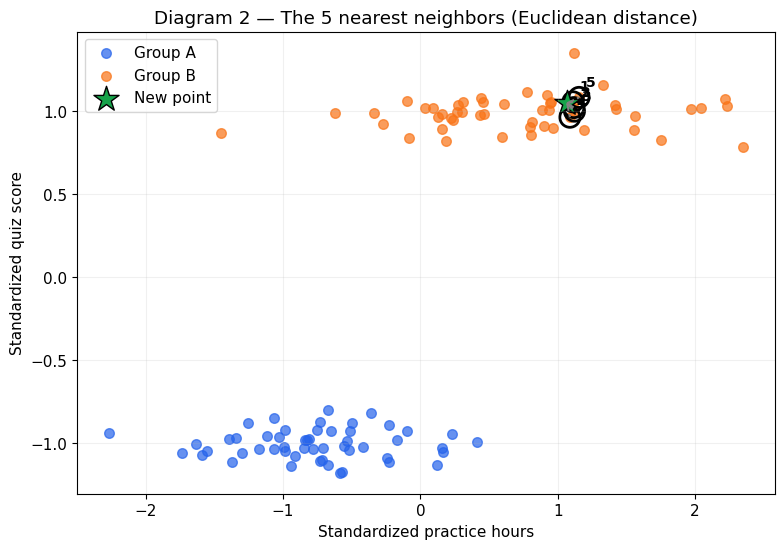

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for label, c in [(0, COLORS[0]), (1, COLORS[1])]:
    pts = X_train_scaled[y_train == label]
    ax.scatter(pts[:, 0], pts[:, 1], s=48, alpha=0.7, color=c, label=f"Group {chr(65+label)}")
for rank, idx in enumerate(indices[0], 1):
    p = X_train_scaled[idx]
    ax.plot([new_scaled[0], p[0]], [new_scaled[1], p[1]], "--", color="gray", linewidth=1.5)
    ax.scatter(p[0], p[1], s=210, facecolors="none", edgecolors="black", linewidths=2)
    ax.annotate(str(rank), (p[0], p[1]), xytext=(5, 8), textcoords="offset points", fontsize=10, weight="bold")
ax.scatter(*new_scaled, marker="*", s=360, color="#16a34a", edgecolor="black", label="New point")
ax.set(xlabel="Standardized practice hours", ylabel="Standardized quiz score", title=f"Diagram 2 — The {K} nearest neighbors (Euclidean distance)")
ax.legend(loc="best")
plt.show()

**Distance formula (after standardization):**

$$d(\mathbf{x},\mathbf{z})=\sqrt{(x_1-z_1)^2+(x_2-z_2)^2}$$

KNN takes a **majority vote** among neighbors for classification. Distance here is measured in standardized feature units, not original hours or quiz points.

## 3. Decision boundaries: small K vs large K
Small K can produce detailed, irregular boundaries (higher variance). Large K creates smoother boundaries, but may underfit. The optimal K is data-dependent; avoid claiming that K=5 is universally best.

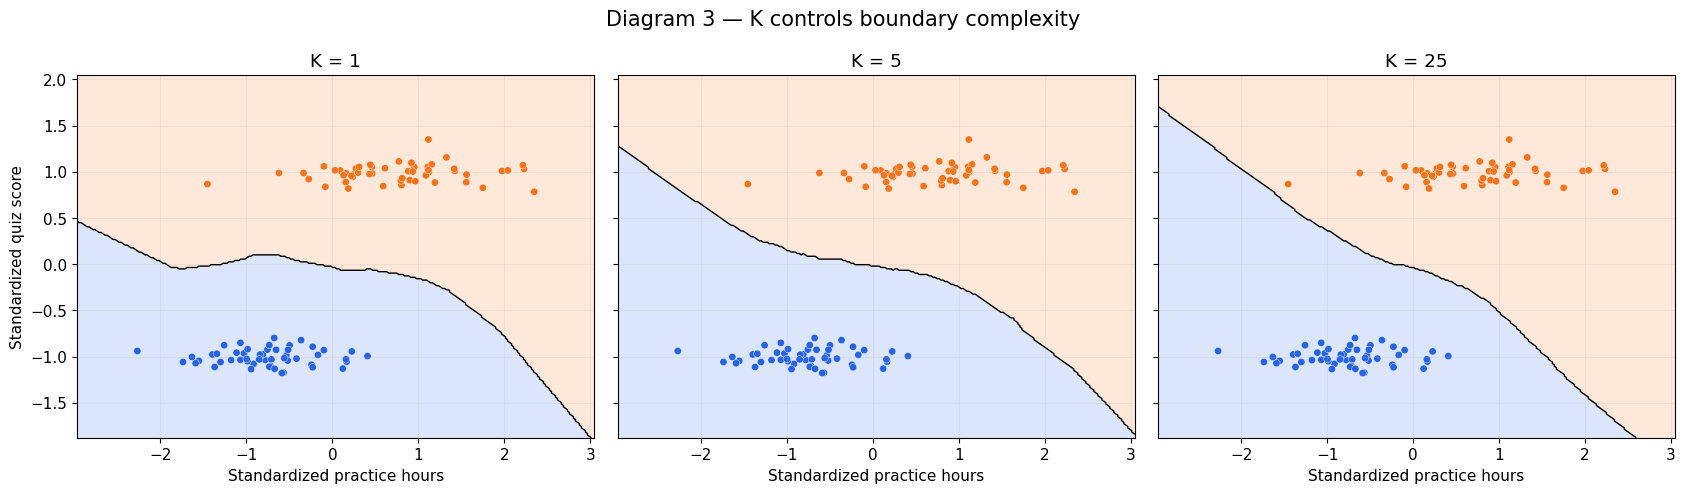

In [6]:
xx, yy = np.meshgrid(np.linspace(X_train_scaled[:,0].min()-0.7, X_train_scaled[:,0].max()+0.7, 260), np.linspace(X_train_scaled[:,1].min()-0.7, X_train_scaled[:,1].max()+0.7, 260))
grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
for ax, k in zip(axes, [1, 5, 25]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    zz = knn.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5,0.5,1.5], colors=COLORS, alpha=0.16)
    ax.contour(xx, yy, zz, levels=[0.5], colors=["black"], linewidths=1)
    ax.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=y_train, cmap=CMAP, vmin=0, vmax=1, s=28, edgecolor="white", linewidth=0.3)
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Standardized practice hours")
axes[0].set_ylabel("Standardized quiz score")
fig.suptitle("Diagram 3 — K controls boundary complexity", fontsize=15)
plt.tight_layout()
plt.show()

## 4. Choose K using cross-validation
We compare **5-fold stratified cross-validation accuracy on training data only**, so the test set stays unseen until final evaluation. We fit a new scaler within each CV fold using a pipeline.

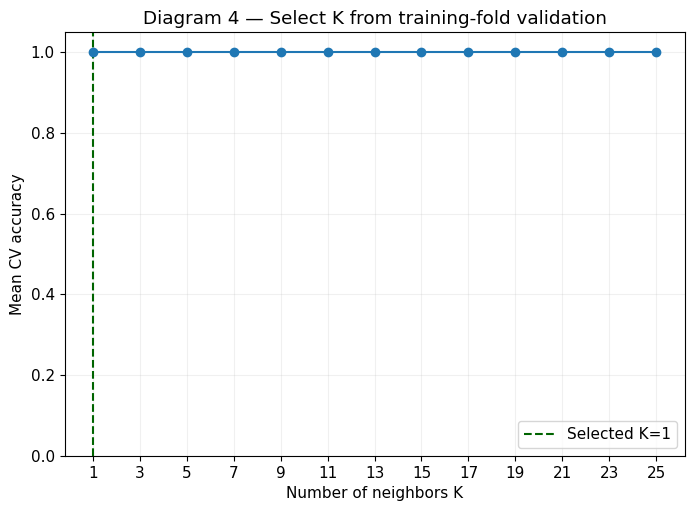

Selected K: 1 (highest mean CV accuracy; first value breaks ties)


In [7]:
k_values = list(range(1, 26, 2))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_means, cv_stds = [], []
for k in k_values:
    pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean()); cv_stds.append(scores.std())
best_k = k_values[int(np.argmax(cv_means))]
fig, ax = plt.subplots()
ax.errorbar(k_values, cv_means, yerr=cv_stds, fmt="o-", capsize=3)
ax.axvline(best_k, color="darkgreen", linestyle="--", label=f"Selected K={best_k}")
ax.set(xlabel="Number of neighbors K", ylabel="Mean CV accuracy", title="Diagram 4 — Select K from training-fold validation", xticks=k_values, ylim=(0,1.05))
ax.legend()
plt.show()
print(f"Selected K: {best_k} (highest mean CV accuracy; first value breaks ties)")

## 5. Final classification test and confusion matrix
Use the selected K to fit the entire training set, then evaluate once on the held-out test set.

Held-out accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

     Group A       1.00      1.00      1.00        18
     Group B       1.00      1.00      1.00        17

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35



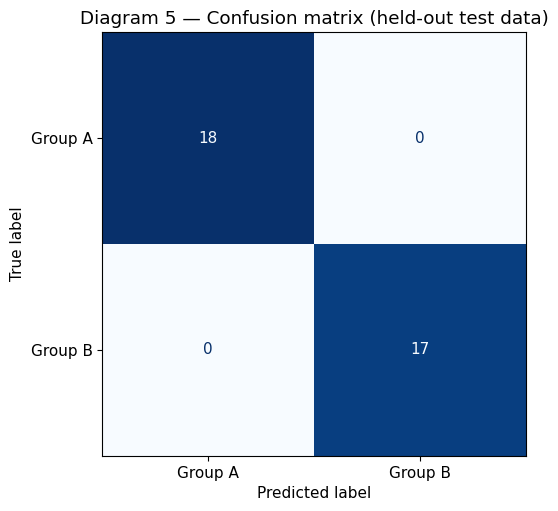

In [8]:
final_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("Held-out accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=["Group A", "Group B"], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Group A", "Group B"], cmap="Blues", colorbar=False)
plt.title("Diagram 5 — Confusion matrix (held-out test data)")
plt.grid(False)
plt.show()

## 6. Why scaling features matters
To isolate the effect of feature scale, compare KNN on **unscaled** vs **scaled** coordinates at the *same* K. Here quiz scores span a larger numeric range than practice hours, which can dominate unscaled Euclidean distance.

,Configuration,Test accuracy
0,Without scaling,1.0
1,With standardization,1.0


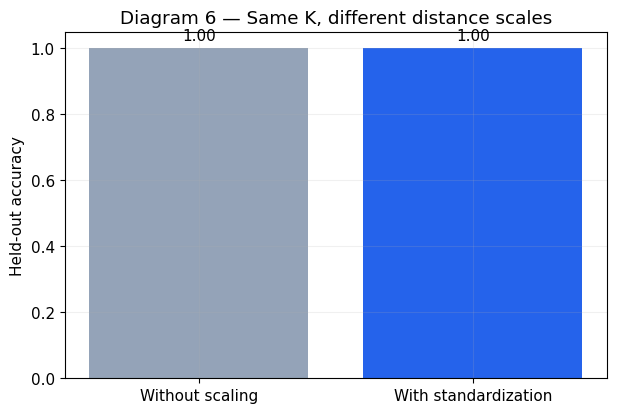

Note: Accuracy may match despite different distance geometry; scaling is still important when feature units differ.


In [9]:
models = {
    "Without scaling": KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train),
    "With standardization": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k)).fit(X_train, y_train)
}
comparison = pd.DataFrame([{"Configuration": name, "Test accuracy": accuracy_score(y_test, model.predict(X_test))} for name, model in models.items()])
display(comparison)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(comparison["Configuration"], comparison["Test accuracy"], color=["#94a3b8", "#2563eb"])
ax.set(ylabel="Held-out accuracy", title="Diagram 6 — Same K, different distance scales", ylim=(0, 1.05))
for i, score in enumerate(comparison["Test accuracy"]): ax.text(i, score+0.025, f"{score:.2f}", ha="center")
plt.show()
print("Note: Accuracy may match despite different distance geometry; scaling is still important when feature units differ.")

## 7. KNN regression: predict a continuous value
For regression, neighbors' **target values are averaged** instead of majority-voted. This example predicts an artificial continuous output from a one-dimensional feature.

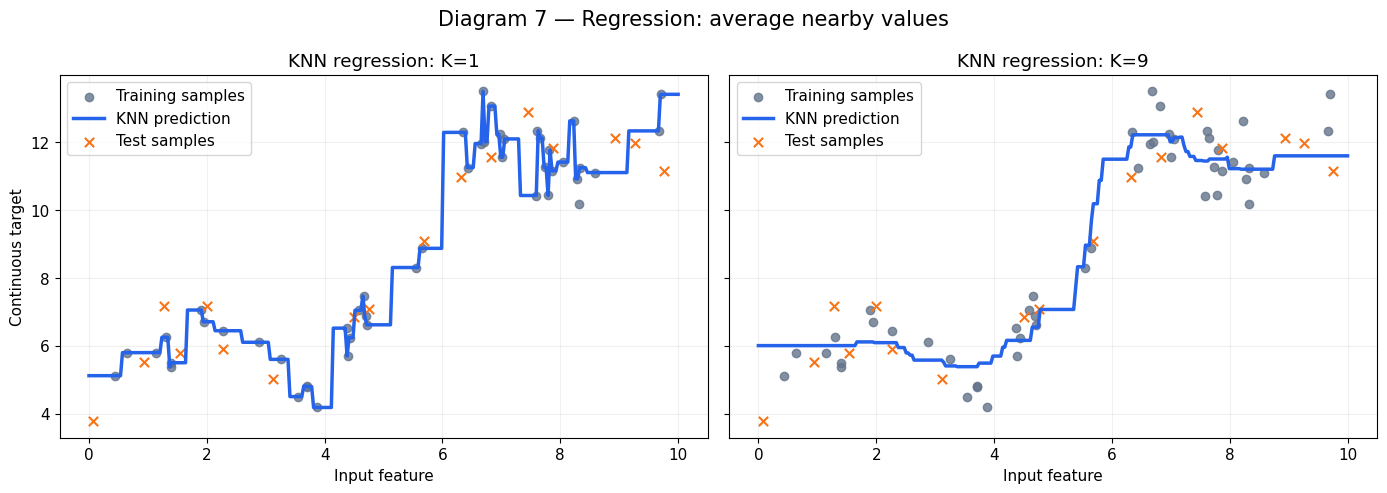

Test MAE: 0.755
Test RMSE: 0.907
Test R²: 0.903


In [10]:
rng = np.random.default_rng(SEED)
x_reg = np.sort(rng.uniform(0, 10, 65))
y_reg = 3 + 1.1*x_reg + 2*np.sin(1.2*x_reg) + rng.normal(0, 0.9, len(x_reg))
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg.reshape(-1,1), y_reg, test_size=0.25, random_state=SEED)
x_line = np.linspace(0, 10, 300).reshape(-1,1)
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True, sharey=True)
for ax, k in zip(axes, [1, 9]):
    model = KNeighborsRegressor(n_neighbors=k).fit(x_train_reg, y_train_reg)
    ax.scatter(x_train_reg, y_train_reg, color="#64748b", alpha=0.8, label="Training samples")
    ax.plot(x_line, model.predict(x_line), color=COLORS[0], linewidth=2.5, label="KNN prediction")
    ax.scatter(x_test_reg, y_test_reg, s=45, marker="x", color=COLORS[1], label="Test samples")
    ax.set(title=f"KNN regression: K={k}", xlabel="Input feature")
    ax.legend()
axes[0].set_ylabel("Continuous target")
fig.suptitle("Diagram 7 — Regression: average nearby values", fontsize=15)
plt.tight_layout()
plt.show()
reg = KNeighborsRegressor(n_neighbors=9).fit(x_train_reg, y_train_reg)
reg_predictions = reg.predict(x_test_reg)
print(f"Test MAE: {mean_absolute_error(y_test_reg, reg_predictions):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, reg_predictions)):.3f}")
print(f"Test R²: {r2_score(y_test_reg, reg_predictions):.3f}")

## 8. Summary and student exercises

**Classification:** majority vote of the K nearest points.

**Regression:** average of neighbors' target values.

**Distance metric:** Euclidean distance (here).

**Important considerations:** scaling, K selection, leakage prevention, imbalanced classes, outliers, and slower prediction on large datasets.

**Try these activities:**
1. Change K in Diagram 2 from `5` to `3` or `9`. Which points are selected?
2. Compare boundaries for K = `1`, `7`, and `35`. What changes?
3. Change the dataset's `cluster_std` to `[3.5, 3.5]`, rerun, and inspect test accuracy.
4. Explain the diagonal of the confusion matrix and the off-diagonal errors.
5. In KNN regression, compare K = `1`, `5`, and `15`: which curve is smoother?
